<img src="assets/header.png" alt="Header" style="display: block; margin: auto; width: 50%;">


# 📚 Import Library yang Digunakan

In [13]:
from sklearn.preprocessing import StandardScaler

In [28]:
from scipy.stats.mstats import winsorize
from scipy.stats import mstats

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns
import pandas as pd
import numpy as np

---

# 💧 Exploratory Data Analysis (EDA) dan Visualisasi Awal Data Kualitas Air
Tahapan ini berfokus pada pemahaman awal terhadap struktur, persebaran, dan kualitas data. Kami akan melakukan EDA serta membuat visualisasi yang menarik dan informatif.

## 📥 Memuat dan Menampilkan Informasi Awal Dataset

In [51]:
water_df = pd.read_csv('./data/water_potability.csv')

In [49]:
print('****'*10)
print(f'Dataframe has {water_df.shape[0]} Rows, {water_df.shape[1]} Columns')
print('****'*10)

water_df.head().style.set_properties(**{'background-color': '#A2DBFA',
                                    'color': 'black',
                                    'border': '1.5px  solid black'}).bar(color='#F3F1F5', 
                                                                         vmin=100_000, 
                                                                         subset=['Potability'])

****************************************
Dataframe has 3276 Rows, 10 Columns
****************************************


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,nan,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,nan,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,nan,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


📌 **Penjelasan** : 
- Dataset berhasil dimuat dengan ukuran 3276 baris dan 10 kolom
- Tampilan data menggunakan styling berwarna biru muda (#A2DBFA) untuk memudahkan pembacaan
- Kolom yang ada meliputi berbagai parameter kualitas air dan target 'Potability'

## 🧾 Melihat Sample Data dan Statistik Deskriptif

In [40]:
water_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


📌 **Penjelasan** : 
- Semua kolom memiliki tipe data float64
- Terdapat missing values di beberapa kolom
- Memory usage teroptimasi

In [41]:
water_df.describe().T.style.bar(subset=['mean'], color='#E68193')\
                            .background_gradient(subset=['std'], cmap='mako_r')\
                             .background_gradient(subset=['50%'], cmap='mako')

,count,mean,std,min,25%,50%,75%,max
ph,2785.000000,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.000000,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.000000,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.000000,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.000000,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.000000,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.000000,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.000000,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.000000,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.000000,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


📌 **Penjelasan** : 
- Visualisasi dengan gradient warna menunjukkan variasi standar deviasi
- Mean dan median ditampilkan dengan bar chart berwarna merah muda (#E68193)

## 🧩 Cek Nilai Unik, Missing Values, dan Duplikasi

In [42]:
# Menampilkan jumlah nilai unik dalam dataset
print("\nJumlah Nilai Unik per Kolom:")
print(water_df.nunique())


Jumlah Nilai Unik per Kolom:
ph                 2785
Hardness           3276
Solids             3276
Chloramines        3276
Sulfate            2495
Conductivity       3276
Organic_carbon     3276
Trihalomethanes    3114
Turbidity          3276
Potability            2
dtype: int64


📌 **Penjelasan** : 
- Mayoritas parameter memiliki nilai unik maksimal (3276), menunjukkan presisi pengukuran tinggi
- pH dan Sulfate memiliki nilai unik lebih sedikit karena missing values
- Target variable bersifat binary, sesuai untuk klasifikas

In [43]:
# Mengecek jumlah missing values
print("\nMissing Values dalam Dataset:")
print(water_df.isnull().sum())


Missing Values dalam Dataset:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


📌 **Penjelasan** : 
- pH: 491 missing values
- Sulfate: 781 missing values
- Trihalomethanes: 162 missing values

In [3]:
# Menampilkan data duplikat
print("\nData Duplikat dalam Dataset:")
print(water_df.duplicated().sum())


Data Duplikat dalam Dataset:
0


📌 **Penjelasan** : 
- Tidak di temukan data duplikat 

# 📊 Visualisasi Data Awal

## 📈 Visualisasi Distribusi Target (`Potability`)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13164\805339094.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




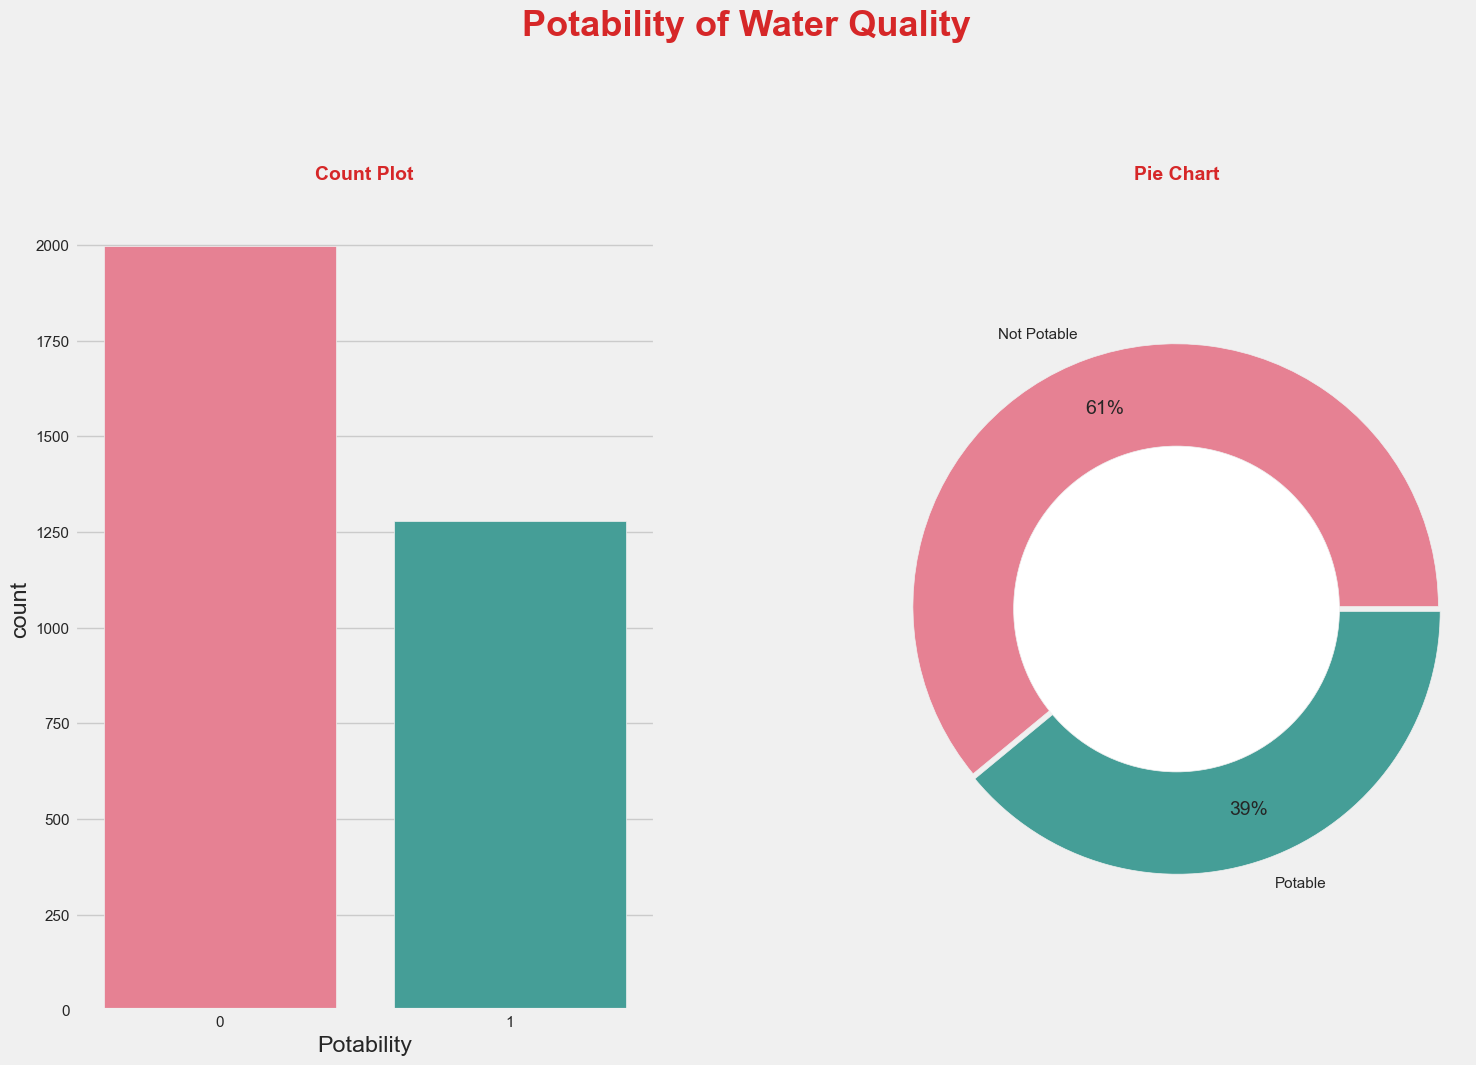

In [45]:
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 11))
fig.suptitle('Potability of Water Quality', size=26, color=theme[3], weight='bold')
axs = [ax1, ax2]

# Count Plot
sns.countplot(x='Potability', data=water_df, ax=ax1, palette='husl', hue=None, legend=False)
ax1.set_title('Count Plot', size=14, color=theme[3], weight='bold', pad=20)

# Pie Chart (Doughnut)
names = ["Not Potable", "Potable"]
values = water_df['Potability'].value_counts().sort_index()
colors = ["#E68193", "#459E97"]
explode = (0.01, 0.01)

# Pie chart
ax2.pie(x=values, labels=names, colors=colors, autopct='%1.0f%%', pctdistance=0.8, explode=explode)

# Doughnut center
centre_circle = plt.Circle((0, 0), 0.62, fc='white')
ax2.add_artist(centre_circle)
ax2.axis('equal')
ax2.set_title('Pie Chart', size=14, color=theme[3], weight='bold', pad=20)

# Layout
plt.subplots_adjust(left=None, bottom=None, right=None, top=0.8, wspace=0.4, hspace=None)
plt.show()


### 🧠 Insight
- Data ini menunjukkan **tantangan besar dalam ketersediaan air bersih**.
- Penting untuk meneliti lebih lanjut faktor-faktor penyebab air tidak layak, seperti:
  - Kandungan kimia berbahaya
  - Tingkat pH tidak seimbang
  - Polusi lingkungan

## 🪄 Distribusi Fitur berdasarkan Potability

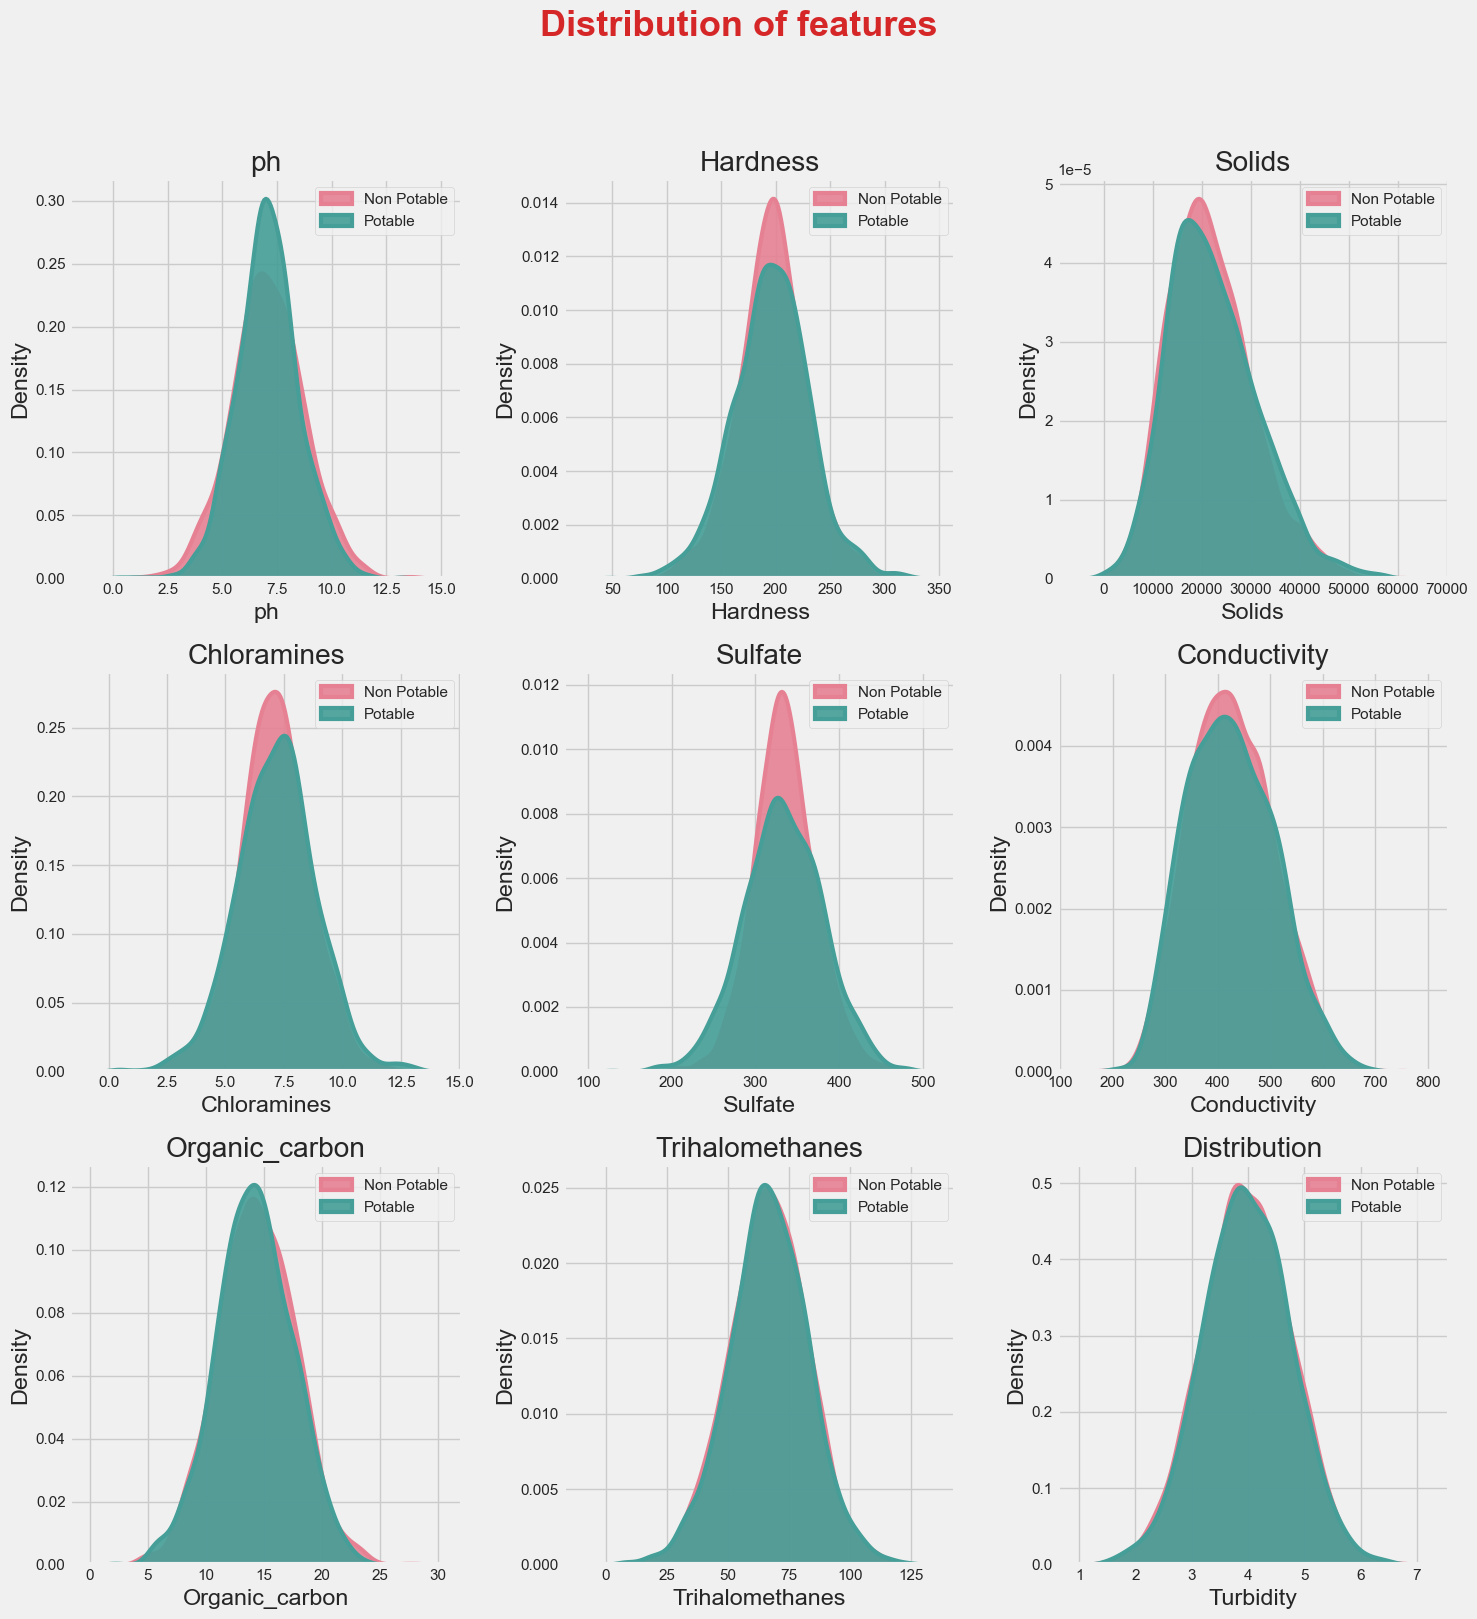

In [46]:
non_potable = water_df.query("Potability == 0")
potable = water_df.query("Potability == 1")

plt.figure(figsize = (15,15))
for ax, col in enumerate(water_df.columns[:9]):
    plt.subplot(3,3, ax + 1)
    plt.title(col)
    plotting = sns.kdeplot(x = non_potable[col], label = "Non Potable",fill=True, common_norm=False, color="#E68193",alpha=.9, linewidth=3)
    plotting = sns.kdeplot(x = potable[col], label = "Potable",fill=True, common_norm=False, color="#459E97",alpha=.9, linewidth=3)
    plt.legend()
plt.tight_layout()
plt.title('Distribution')
plotting.figure.suptitle(' Distribution of features ',y=1.08, size = 26, color = theme[3], weight='bold');

### 🧠 Kesimpulan Umum
- Beberapa fitur seperti pH, sulfate, solids, dan turbidity tampak cukup berbeda distribusinya antara air yang layak dan tidak.
- Fitur-fitur ini bisa sangat relevan untuk pemodelan prediksi kelayakan air 💡




## ♨️ Korelasi antar Fitur

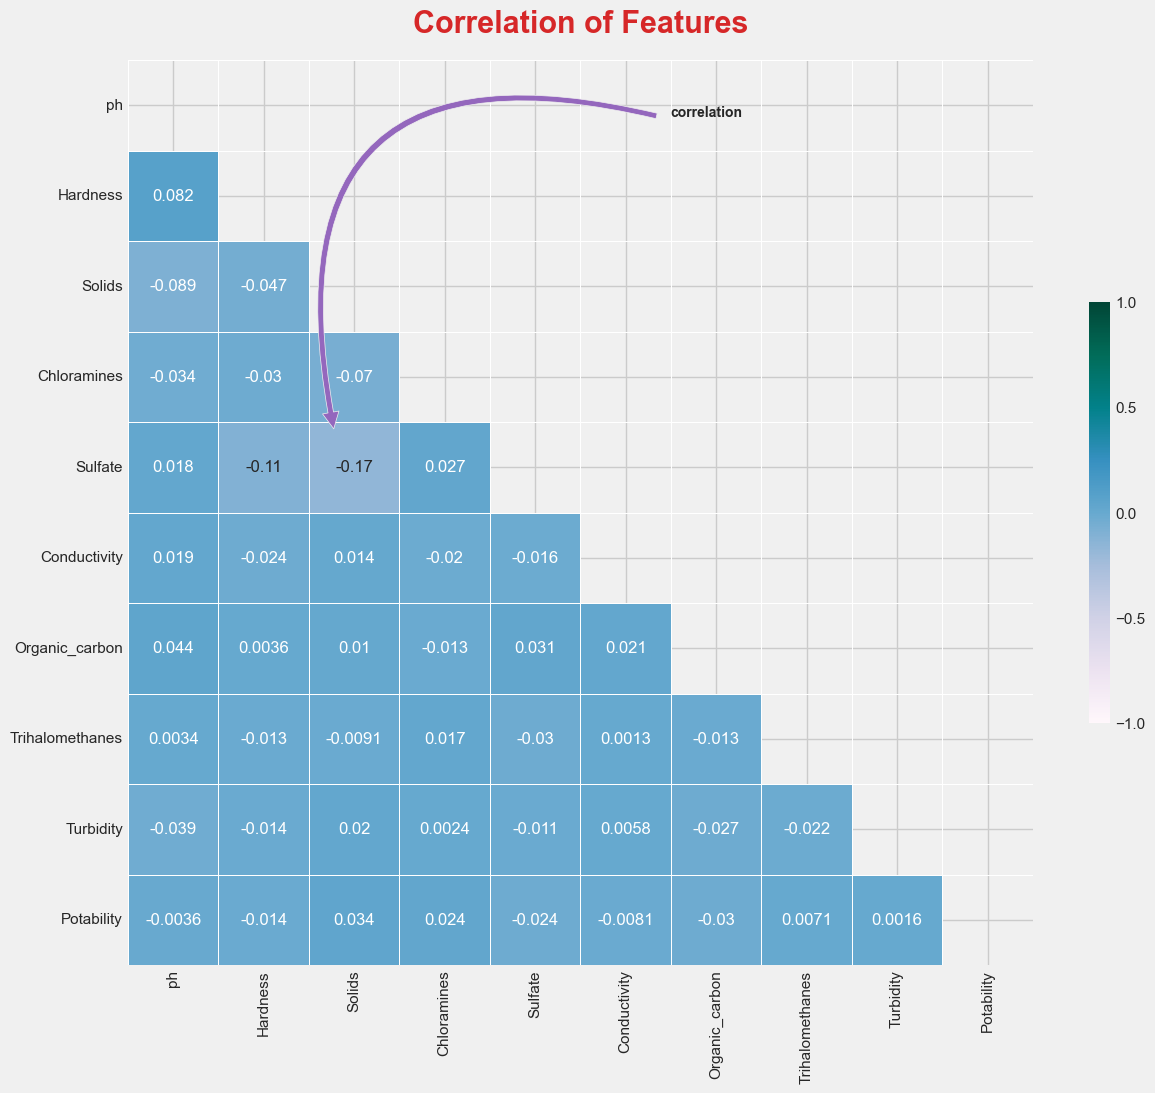

In [47]:
# Define theme colors if not already defined
theme = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
         '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Create correlation matrix mask
mask = np.zeros_like(water_df.corr(), dtype=bool)  # Changed from np.bool to bool
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(13, 13))

heatmap = sns.heatmap(water_df.corr(),
                      mask=mask,
                      square=True,
                      linewidths=.5,
                      cmap='PuBuGn',
                      cbar_kws={'shrink': .4, "ticks": [-1, -.5, 0, 0.5, 1]},
                      vmin=-1,
                      vmax=1,
                      annot=True,
                      annot_kws={"size": 12})

# Add column names as labels
ax.set_yticklabels(water_df.corr(), rotation=0)
ax.set_xticklabels(water_df.corr())

sns.set_style({'xtick.bottom': True}, {'ytick.left': True})

# Add correlation annotation
ax.annotate('correlation',
           fontsize=10,
           fontweight='bold',
           xy=(2.3, 4.2),
           xycoords='data',
           xytext=(0.6, 0.95),
           textcoords='axes fraction',
           arrowprops=dict(
               facecolor=theme[4],
               shrink=0.025,
               connectionstyle='arc3, rad=0.80'),
           horizontalalignment='left',
           verticalalignment='top')

ax.set_title('Correlation of Features', size=22, color=theme[3], weight='bold', pad=20)

plt.show()

### 🎯 Insight Penting
- Sebagian besar fitur memiliki korelasi rendah atau tidak signifikan satu sama lain, menandakan bahwa fitur-fitur dalam dataset ini relatif independen.
- Tidak ada hubungan linier yang kuat dengan fitur Potability, menunjukkan bahwa pendekatan machine learning mungkin diperlukan untuk memahami pola kompleks.



## 🧯 Analisis Visualisasi Outlier

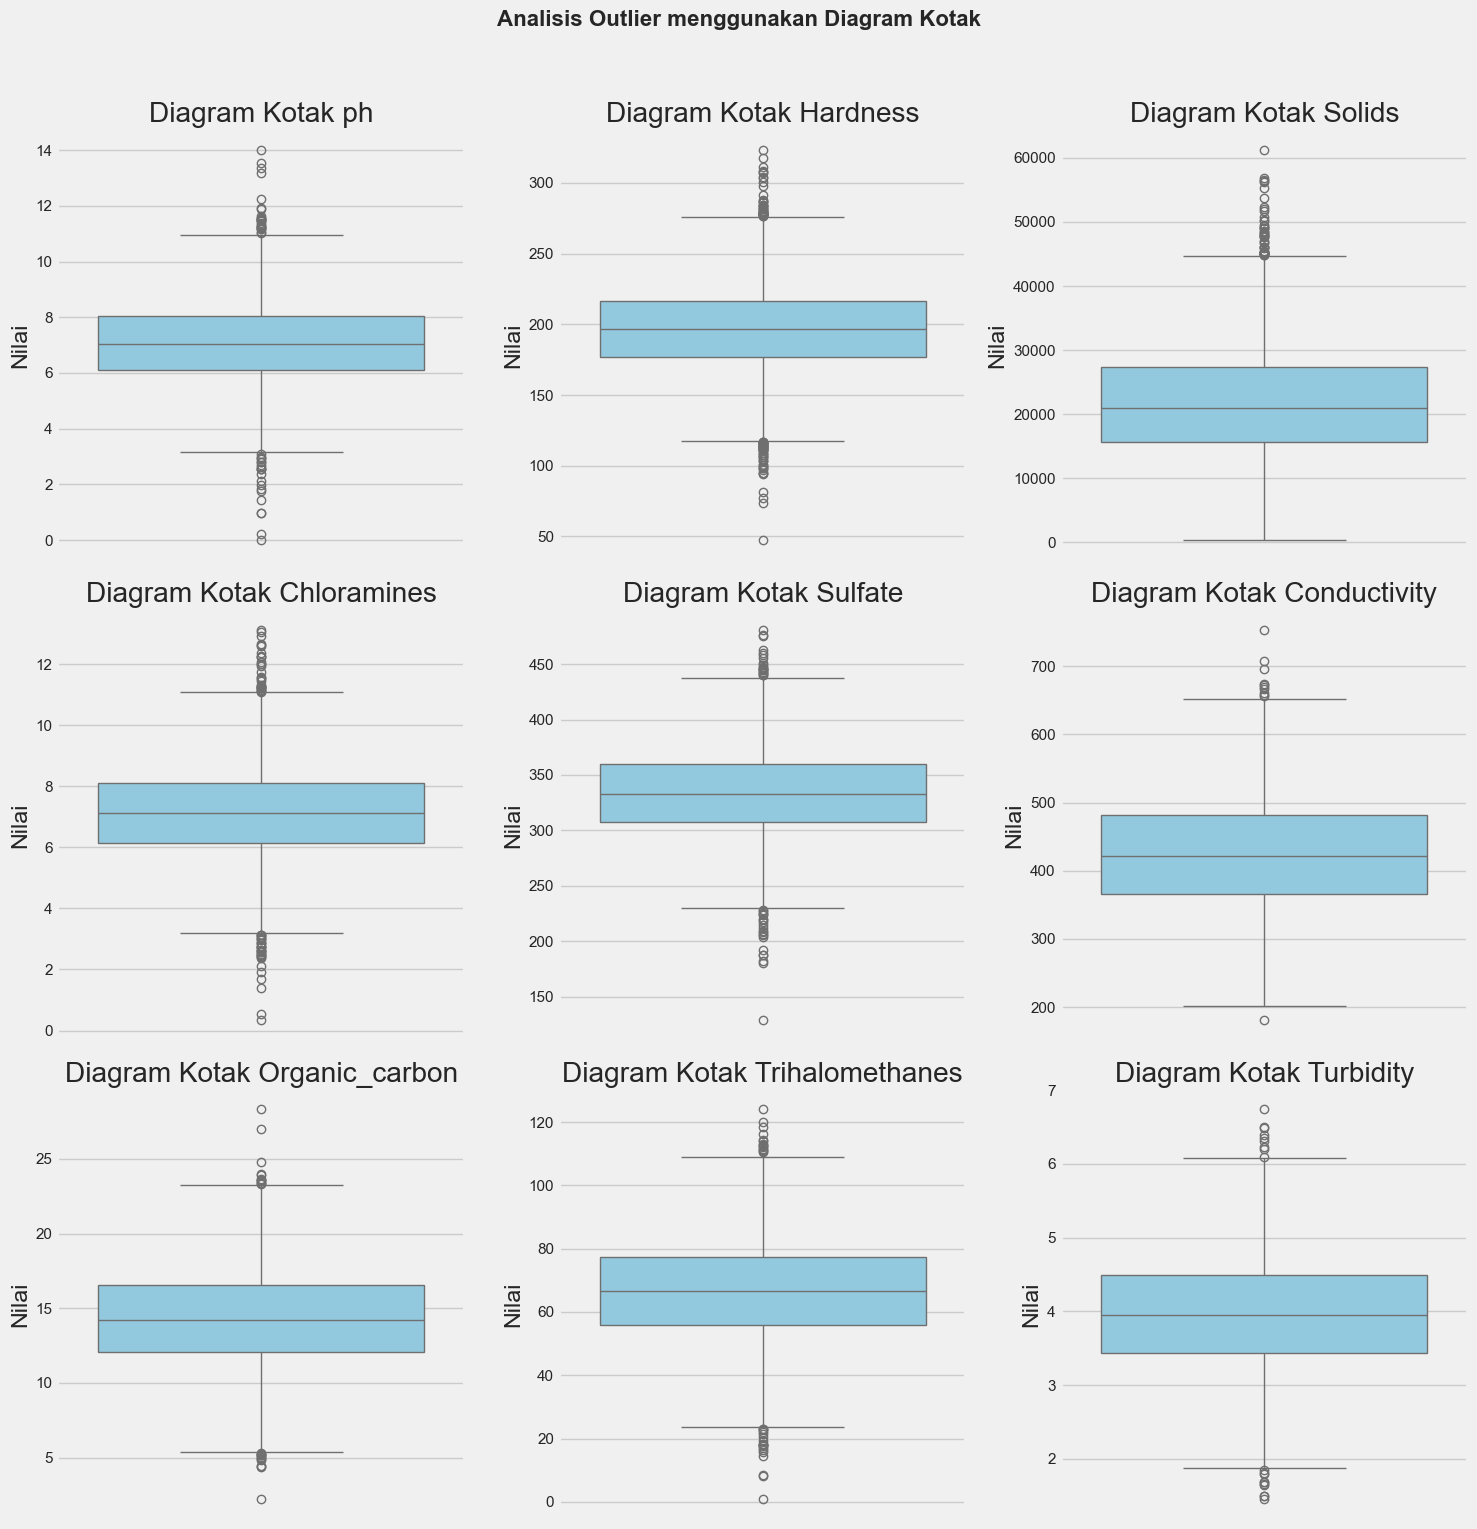


Ringkasan Jumlah Pencilan (Outlier) per Kolom:
Kolom ph: 46 pencilan
Kolom Hardness: 83 pencilan
Kolom Solids: 47 pencilan
Kolom Chloramines: 61 pencilan
Kolom Sulfate: 41 pencilan
Kolom Conductivity: 11 pencilan
Kolom Organic_carbon: 25 pencilan
Kolom Trihalomethanes: 33 pencilan
Kolom Turbidity: 19 pencilan
Kolom Potability: 0 pencilan


In [58]:
# Membuat subplot untuk setiap fitur
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.ravel()

for idx, col in enumerate(water_df.columns[:-1]):  # Mengecualikan variabel target
    sns.boxplot(data=water_df, y=col, ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Diagram Kotak {col}')
    axes[idx].set_ylabel('Nilai')  # Menambahkan label sumbu y
    
plt.suptitle('Analisis Outlier menggunakan Diagram Kotak', 
             size=16, 
             weight='bold',
             y=1.02)
plt.tight_layout()
plt.show()

# Mencetak detail outlier
print("\nRingkasan Jumlah Pencilan (Outlier) per Kolom:")
for col, count in outliers.items():
    print(f"Kolom {col}: {count} pencilan")

### 📌 Kesimpulan Akhir Analisis Outlier

Berdasarkan analisis boxplot terhadap setiap fitur:

- **Seluruh fitur numerik (kecuali `Potability`) mengandung pencilan (outlier)** dalam jumlah bervariasi.
- **Fitur `Hardness` dan `Chloramines` memiliki jumlah outlier tertinggi**, menunjukkan variabilitas data yang signifikan.
- **`Potability` tidak memiliki outlier**, karena kemungkinan merupakan fitur kategorikal (0 atau 1).
- **Outlier perlu ditangani** (misalnya dengan normalisasi, transformasi, atau penghapusan) agar tidak memengaruhi kinerja model machine learning secara negatif.

---

# 🧹 Tahap Pra-pemrosesan Data

###  📌 Penanganan Missing Values
Beberapa fitur pada dataset `water_df` mengandung nilai hilang (`NaN`). Kita mengatasinya dengan mengganti nilai tersebut menggunakan **median**, agar lebih tahan terhadap outlier dibandingkan mean.

In [52]:
water_df['ph'] = water_df['ph'].fillna(water_df['ph'].median())
water_df['Sulfate'] = water_df['Sulfate'].fillna(water_df['Sulfate'].median())
water_df['Trihalomethanes'] = water_df['Trihalomethanes'].fillna(water_df['Trihalomethanes'].median())


#### ✅ **Strategi Penanganan Missing Value Dataset Water Potability**

| Fitur             | Jumlah Missing | Rekomendasi Penanganan           | Alasan Pemilihan Strategi                                      |
|-------------------|----------------|----------------------------------|-----------------------------------------------------------------|
| `ph`              | 491            | **Imputasi dengan median**       | Nilai pH bersifat numerik kontinu, rentangnya terbatas (6.5–8.5 menurut WHO). Median lebih tahan terhadap outlier dibanding mean. |
| `Sulfate`         | 781            | **Imputasi dengan median**       | Sulfat juga numerik kontinu dan punya outlier, jadi median lebih aman. Selain itu, ~24% data hilang — imputasi menjaga ukuran data. |
| `Trihalomethanes` | 162            | **Imputasi dengan median atau KNN Imputer** | Jumlah missing ~5% masih wajar. Jika ingin lebih akurat, bisa gunakan **KNN Imputer** agar mempertimbangkan nilai-nilai fitur lain yang berkorelasi.|



#### 📌 **Alasan Umum Mengapa Tidak Menghapus Missing Rows**
- Jika Anda **menghapus semua baris yang memiliki missing value**, maka Anda akan kehilangan **banyak data (sekitar 43% dari dataset!)**, karena:
  - `ph`: 491/3276 ≈ 15%
  - `Sulfate`: 781/3276 ≈ 24%
  - `Trihalomethanes`: 162/3276 ≈ 5%
- Ini bisa menyebabkan model kurang belajar dengan baik karena data tidak mencukupi, dan potensi bias meningkat.

🔍 **Cek sisa missing values:**

In [53]:
water_df.isnull().sum()


ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

**✅ Semua kolom kini memiliki 0 missing values.**

### 🧯 Penanganan Outlier dengan Winsorization

Untuk mengurangi pengaruh outlier ekstrem, dilakukan **Winsorization** pada 9 fitur numerik dengan batas 5% di setiap sisi distribusi.

In [54]:
# Misal water_df sudah ter-load
columns_to_process = ['ph', 'Hardness', 'Solids', 'Chloramines',
                      'Sulfate', 'Conductivity', 'Organic_carbon',
                      'Trihalomethanes', 'Turbidity']

# 1) Winsorize 5% dan konversi ke np.array untuk setiap kolom
for col in columns_to_process:
    masked = winsorize(water_df[col], limits=[0.05, 0.05])
    water_df[col] = np.asarray(masked)  # atau masked.data

# Setelah ini, warning partition seharusnya hilang
print("🔍 Ringkasan Jumlah Outlier Setelah Winsorization:")
def count_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lb, ub = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((s < lb) | (s > ub)).sum()

for col in columns_to_process:
    print(f"{col}: {count_outliers(water_df[col])} outlier tersisa")

🔍 Ringkasan Jumlah Outlier Setelah Winsorization:
ph: 0 outlier tersisa
Hardness: 0 outlier tersisa
Solids: 0 outlier tersisa
Chloramines: 0 outlier tersisa
Sulfate: 0 outlier tersisa
Conductivity: 0 outlier tersisa
Organic_carbon: 0 outlier tersisa
Trihalomethanes: 0 outlier tersisa
Turbidity: 0 outlier tersisa


**🟢 Seluruh fitur telah bersih dari outlier ekstrem setelah transformasi.**

### 📏 Normalisasi Data dengan StandardScaler

Langkah terakhir adalah **scaling** menggunakan `StandardScaler` agar semua fitur memiliki distribusi dengan rata-rata 0 dan standar deviasi 1.

In [55]:
# 2) Scaling dengan StandardScaler
scaler = StandardScaler()
water_df[columns_to_process] = scaler.fit_transform(water_df[columns_to_process])

print("\n✅ Contoh data setelah winsorization & scaling:")
print(water_df[columns_to_process].head())


✅ Contoh data setelah winsorization & scaling:
         ph  Hardness    Solids  Chloramines   Sulfate  Conductivity  \
0 -0.032425  0.295390 -0.139335     0.122910  1.133746      1.841667   
1 -1.876767 -1.887201 -0.410001    -0.348086 -0.021542      1.869154   
2  0.799352  0.962772 -0.249765     1.522281 -0.021542     -0.092363   
3  0.969753  0.622528  0.014341     0.660596  0.754647     -0.826934   
4  1.576892 -0.525269 -0.491539    -0.410874 -0.769217     -0.360434   

   Organic_carbon  Trihalomethanes  Turbidity  
0       -1.295832         1.458697  -1.409711  
1        0.299752        -0.715495   0.751078  
2        0.861047         0.000045  -1.279295  
3        1.382208         1.803381   0.931126  
4       -0.904103        -1.884543   0.152978  


**📌 Data telah siap digunakan untuk pelatihan model machine learning.**